# 01 — Exploratory Data Analysis

Load the data and look at distributions, missing values, correlations and how the features relate to 30-day readmission.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load import load_raw
from src.data.clean import drop_id
from src.viz.plots import plot_target_balance
from src.config import TARGET, FIGURES_DIR, TABLES_DIR

sns.set_theme(style='whitegrid')

In [2]:
df = drop_id(load_raw())
df.shape

(3000, 15)

In [3]:
df.head()

,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      3000 non-null   int64  
 1   gender                   3000 non-null   object 
 2   bmi                      2910 non-null   float64
 3   bnp                      3000 non-null   int64  
 4   sodium                   2910 non-null   float64
 5   creatinine               2910 non-null   float64
 6   systolic_bp              3000 non-null   int64  
 7   heart_rate               3000 non-null   int64  
 8   ace_inhibitor            3000 non-null   int64  
 9   beta_blocker             3000 non-null   int64  
 10  diuretic                 3000 non-null   int64  
 11  adherence_score          3000 non-null   float64
 12  income_level             3000 non-null   object 
 13  distance_to_hospital_km  3000 non-null   float64
 14  readmitted_30d          

In [5]:
# split columns into numeric, binary and categorical
num = df.select_dtypes('number').drop(columns=[TARGET]).columns.tolist()
binary = [c for c in num if df[c].dropna().isin([0, 1]).all()]
num = [c for c in num if c not in binary]
cat = df.select_dtypes(exclude='number').columns.tolist() + binary
print('numeric:', num)
print('categorical:', cat)

numeric: ['age', 'bmi', 'bnp', 'sodium', 'creatinine', 'systolic_bp', 'heart_rate', 'adherence_score', 'distance_to_hospital_km']
categorical: ['gender', 'income_level', 'ace_inhibitor', 'beta_blocker', 'diuretic']


In [6]:
types = pd.DataFrame({'variable': df.columns})
types['kind'] = types['variable'].apply(
    lambda c: 'target' if c == TARGET else 'numeric' if c in num else 'categorical')
types['dtype'] = types['variable'].map(df.dtypes.astype(str))
types['missing'] = types['variable'].map(df.isna().sum())
types.to_csv(TABLES_DIR / 'tbl_variable_types.csv', index=False)
types

,variable,kind,dtype,missing
0,age,numeric,int64,0
1,gender,categorical,object,0
2,bmi,numeric,float64,90
3,bnp,numeric,int64,0
4,sodium,numeric,float64,90
5,creatinine,numeric,float64,90
6,systolic_bp,numeric,int64,0
7,heart_rate,numeric,int64,0
8,ace_inhibitor,categorical,int64,0
9,beta_blocker,categorical,int64,0


In [7]:
summary = df[num].describe().T.round(2)
summary.to_csv(TABLES_DIR / 'tbl_numeric_summary.csv')
summary

,count,mean,std,min,25%,50%,75%,max
age,3000.0,65.25,14.81,40.00,52.00,65.00,78.00,90.00
bmi,2910.0,28.11,4.95,8.80,24.80,28.10,31.50,44.90
bnp,3000.0,406.31,232.27,50.00,225.00,392.00,569.00,1381.00
sodium,2910.0,138.09,4.03,124.70,135.30,138.10,140.80,151.60
creatinine,2910.0,1.20,0.49,-0.59,0.87,1.20,1.52,2.94
systolic_bp,3000.0,129.59,20.26,61.00,116.00,130.00,143.00,196.00
heart_rate,3000.0,79.36,15.27,19.00,69.00,79.00,90.00,147.00
adherence_score,3000.0,0.70,0.17,0.40,0.55,0.70,0.85,1.00
distance_to_hospital_km,3000.0,25.40,14.15,1.00,12.80,25.45,37.52,50.00


In [8]:
rows = []
for c in cat:
    for level, count in df[c].value_counts().items():
        rows.append({'variable': c, 'level': level, 'count': int(count),
                     'pct': round(count / len(df) * 100, 2)})
freq = pd.DataFrame(rows)
freq.to_csv(TABLES_DIR / 'tbl_categorical_freq.csv', index=False)
freq

,variable,level,count,pct
0,gender,Male,1508,50.27
1,gender,Female,1492,49.73
2,income_level,Low,1024,34.13
3,income_level,Medium,998,33.27
4,income_level,High,978,32.60
5,ace_inhibitor,1,1565,52.17
6,ace_inhibitor,0,1435,47.83
7,beta_blocker,1,1510,50.33
8,beta_blocker,0,1490,49.67
9,diuretic,0,1533,51.10


readmitted_30d
0    0.589
1    0.411
Name: proportion, dtype: float64

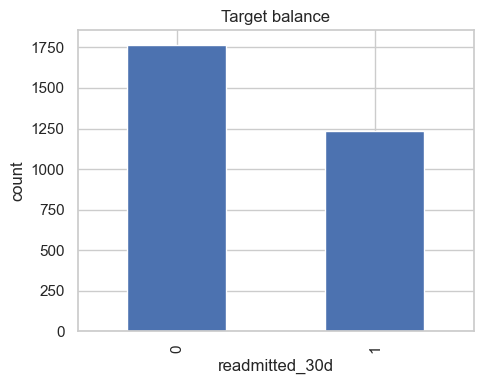

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_target_balance(df, TARGET, ax=ax)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_target_balance.png', dpi=120)
df[TARGET].value_counts(normalize=True).round(3)

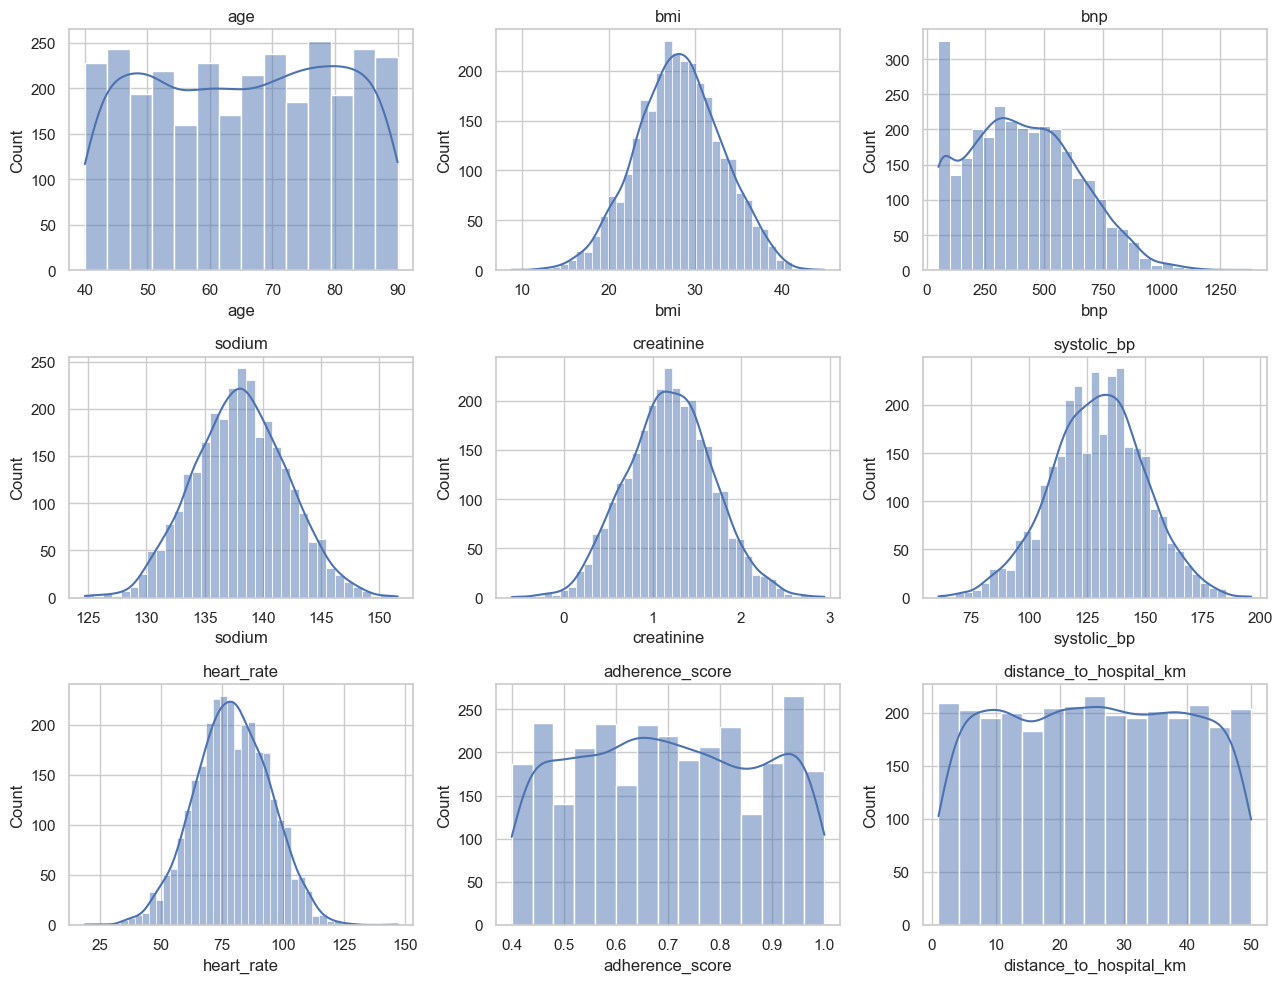

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, c in zip(axes.ravel(), num):
    sns.histplot(df[c].dropna(), kde=True, ax=ax)
    ax.set_title(c)
for ax in axes.ravel()[len(num):]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_hist_numeric.png', dpi=120)

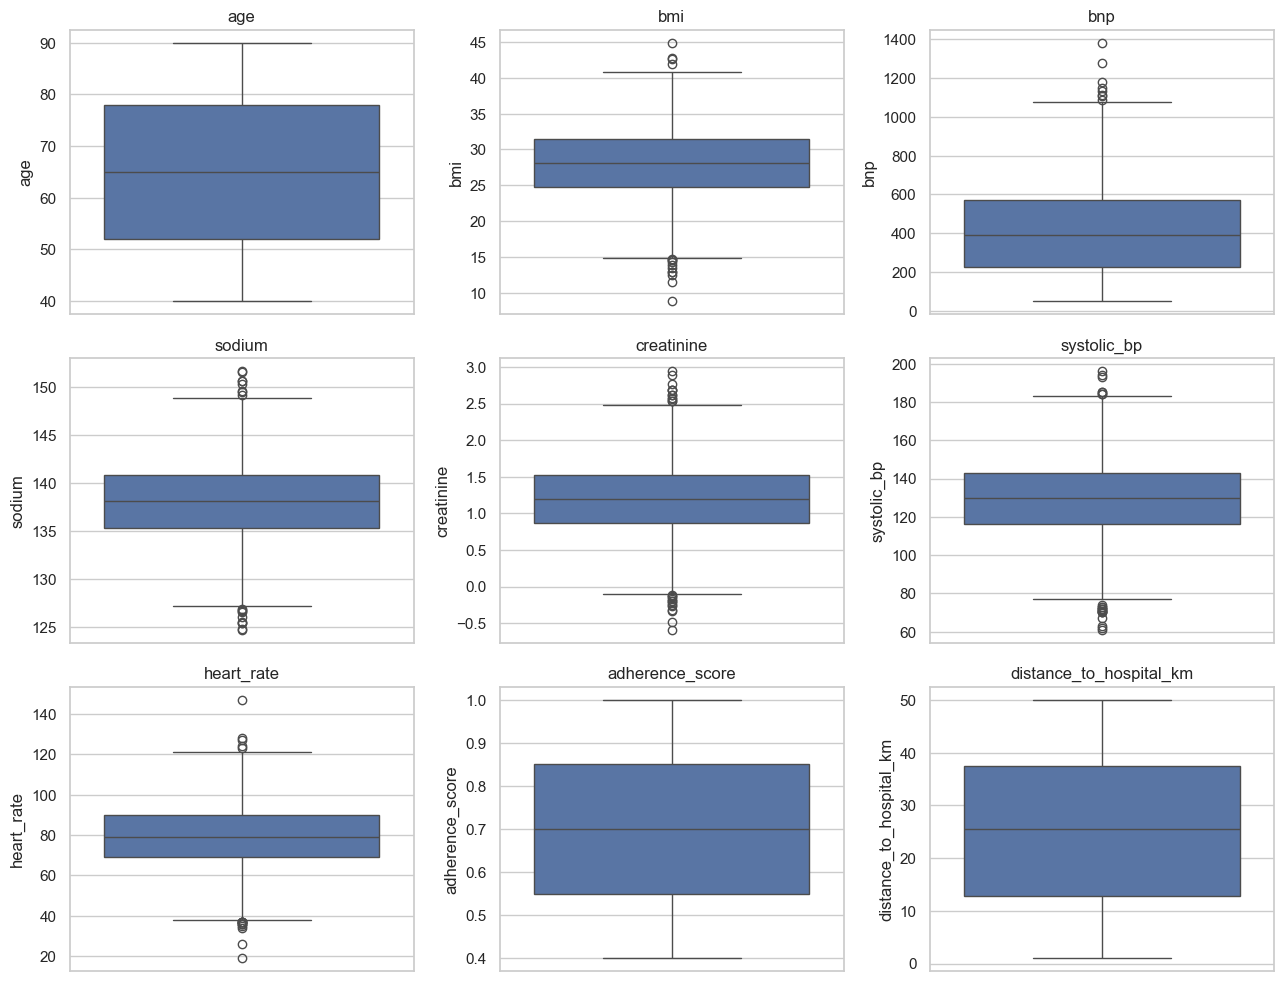

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, c in zip(axes.ravel(), num):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
for ax in axes.ravel()[len(num):]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_box_numeric.png', dpi=120)

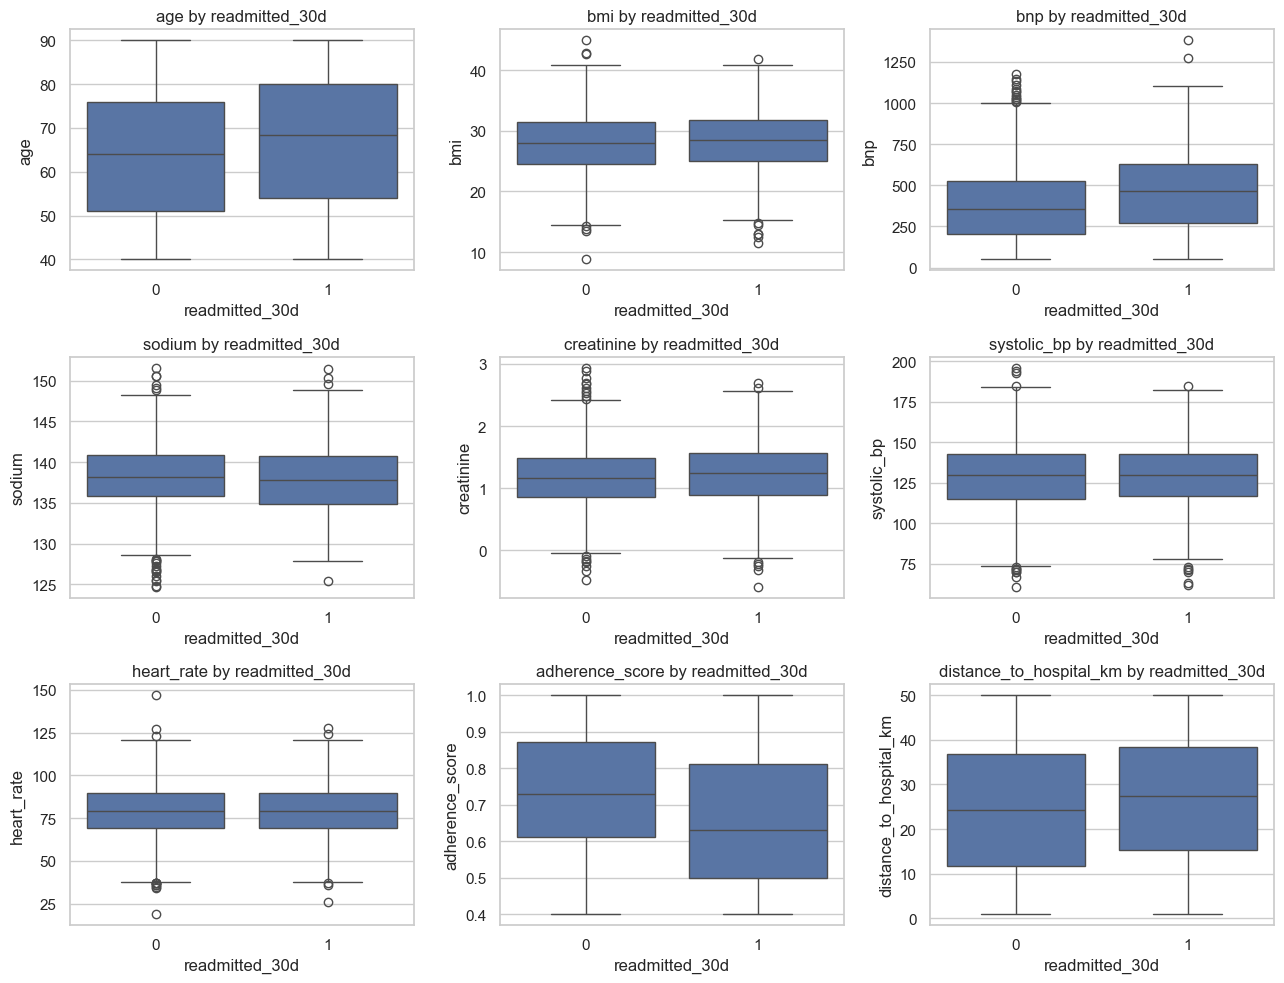

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, c in zip(axes.ravel(), num):
    sns.boxplot(x=df[TARGET], y=df[c], ax=ax)
    ax.set_title(f'{c} by {TARGET}')
for ax in axes.ravel()[len(num):]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_box_by_target.png', dpi=120)

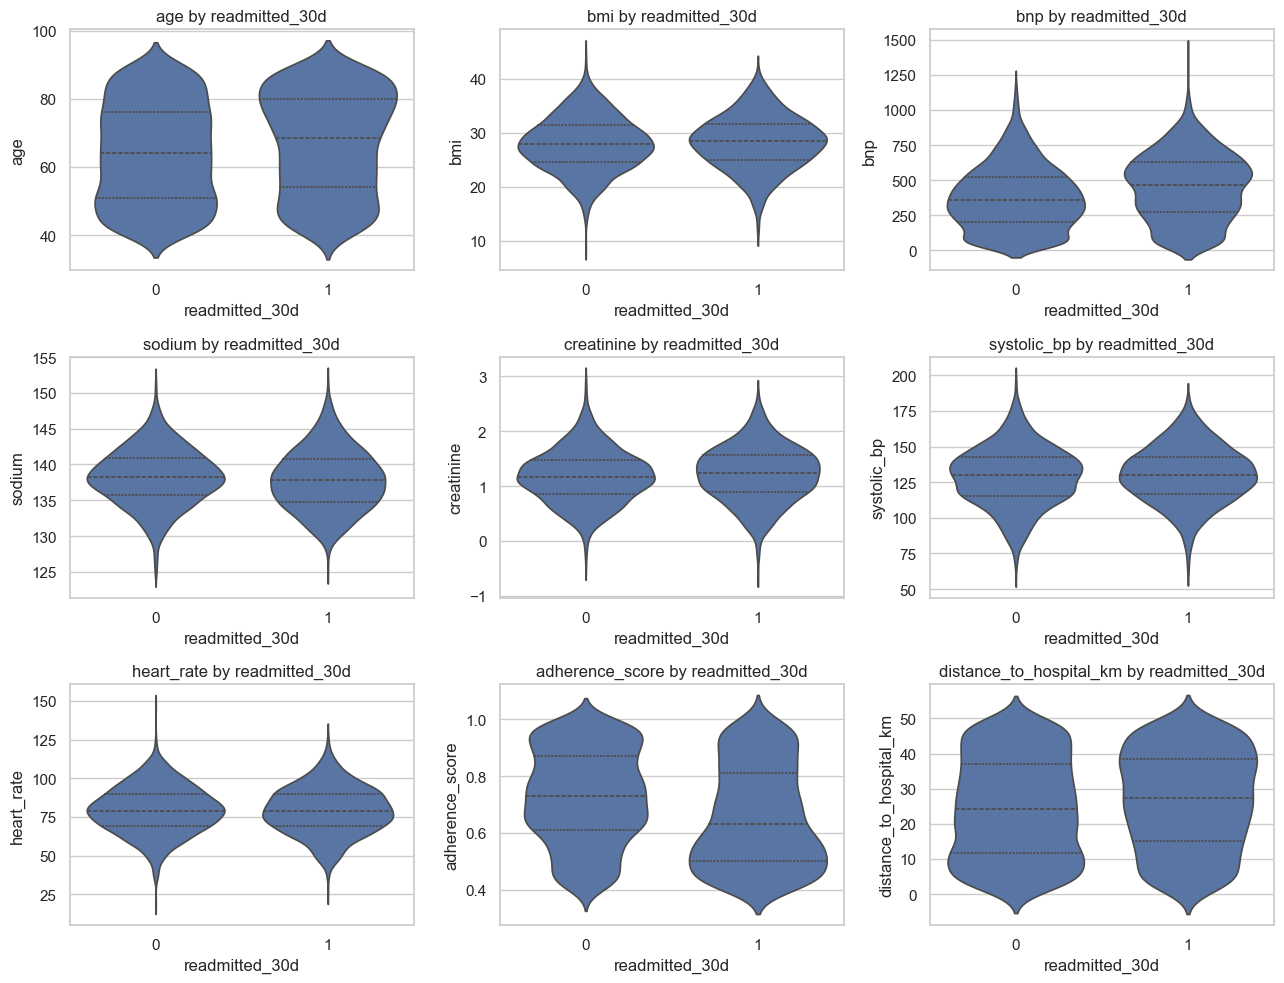

In [13]:
# violin plots show the full distribution shape per readmission group
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, c in zip(axes.ravel(), num):
    sns.violinplot(x=df[TARGET], y=df[c], inner='quartile', ax=ax)
    ax.set_title(f'{c} by {TARGET}')
for ax in axes.ravel()[len(num):]:
    ax.axis('off')
fig.tight_layout()

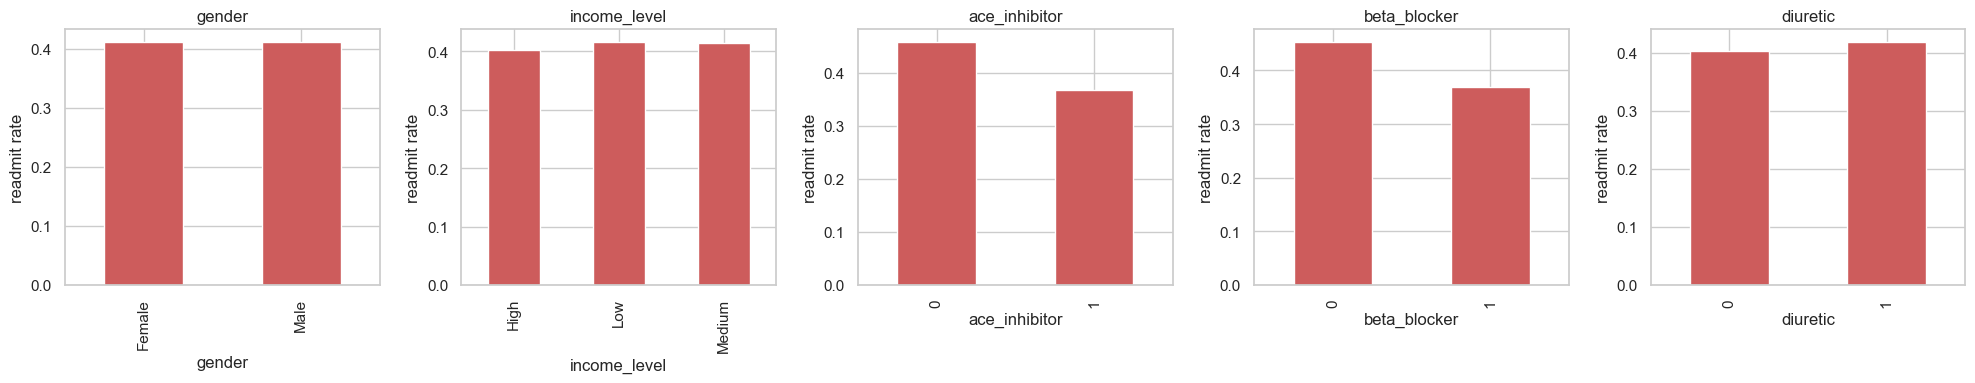

In [14]:
fig, axes = plt.subplots(1, len(cat), figsize=(4 * len(cat), 4))
for ax, c in zip(np.ravel(axes), cat):
    df.groupby(c)[TARGET].mean().plot.bar(ax=ax, color='indianred')
    ax.set_ylabel('readmit rate')
    ax.set_title(c)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_bar_categorical.png', dpi=120)

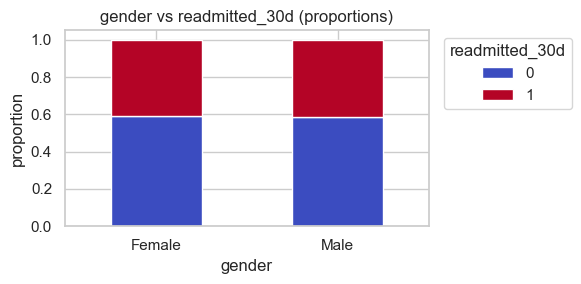

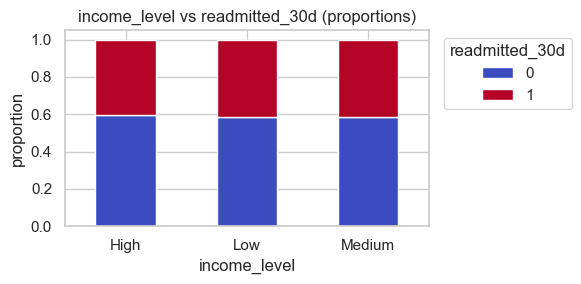

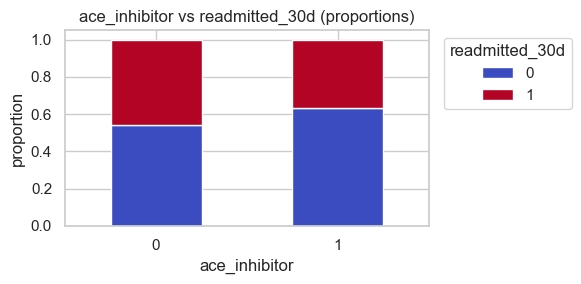

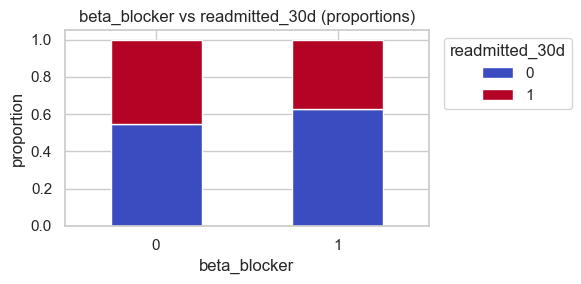

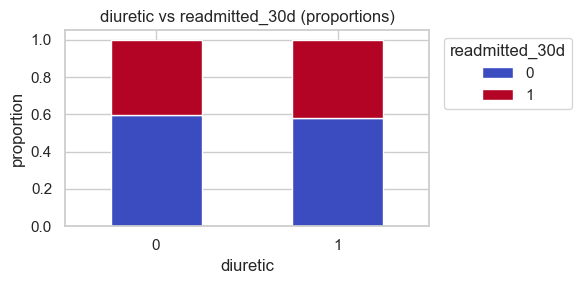

In [15]:
# proportion of each readmission class within every categorical level
for c in cat:
    prop = pd.crosstab(df[c], df[TARGET], normalize='index')
    prop.plot(kind='bar', stacked=True, figsize=(6, 3), colormap='coolwarm')
    plt.title(f'{c} vs {TARGET} (proportions)')
    plt.ylabel('proportion')
    plt.xticks(rotation=0)
    plt.legend(title=TARGET, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

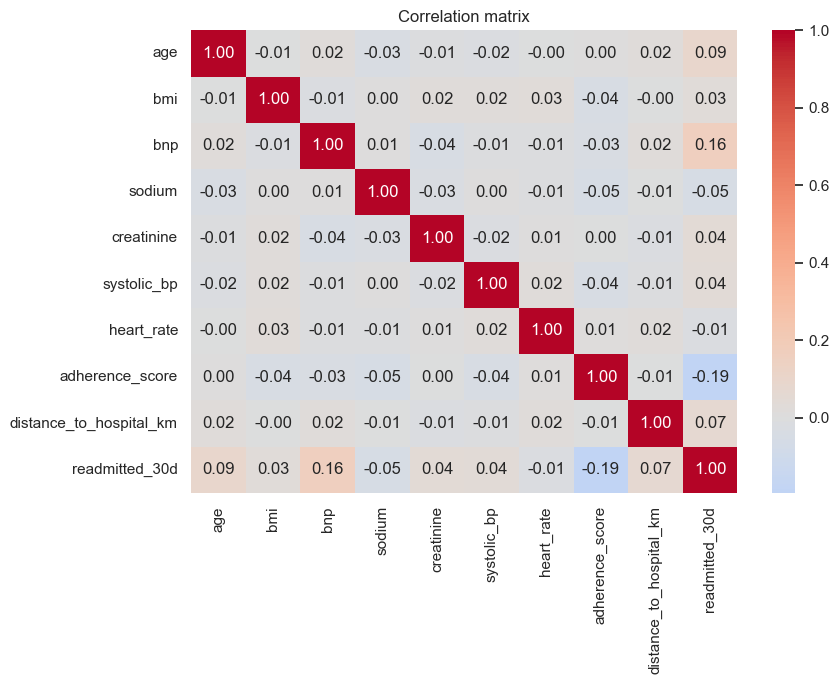

In [16]:
corr = df[num + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation matrix')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_corr_heatmap.png', dpi=120)
corr.round(2).to_csv(TABLES_DIR / 'tbl_correlations.csv')

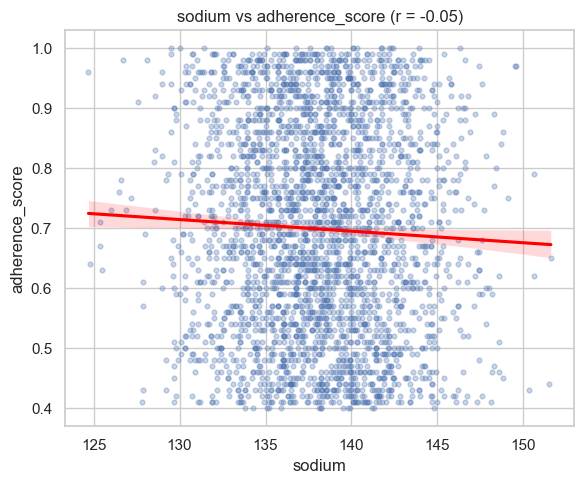

In [17]:
c = df[num].corr().abs()
np.fill_diagonal(c.values, 0)
a, b = c.stack().idxmax()
fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(x=df[a], y=df[b], ax=ax,
            scatter_kws={'alpha': 0.3, 's': 12}, line_kws={'color': 'red'})
ax.set_title(f'{a} vs {b} (r = {df[a].corr(df[b]):.2f})')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig_scatter_reg.png', dpi=120)

## Outliers and encoding

In [18]:
# IQR rule: count values more than 1.5*IQR outside the quartiles
rows = []
for c in num:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    rows.append({'feature': c, 'lower': round(lo, 2), 'upper': round(hi, 2),
                 'n_outliers': int(((df[c] < lo) | (df[c] > hi)).sum())})
pd.DataFrame(rows)

,feature,lower,upper,n_outliers
0,age,13.00,117.00,0
1,bmi,14.75,41.55,15
2,bnp,-291.00,1085.00,8
3,sodium,127.05,149.05,18
4,creatinine,-0.11,2.50,25
5,systolic_bp,75.50,183.50,22
6,heart_rate,37.50,121.50,17
7,adherence_score,0.10,1.30,0
8,distance_to_hospital_km,-24.29,74.61,0


In [19]:
# what one-hot encoding does to the categorical columns
obj_cols = df.select_dtypes(exclude='number').columns.tolist()
encoded = pd.get_dummies(df, columns=obj_cols, drop_first=True)
print('shape before:', df.shape, '-> after one-hot:', encoded.shape)
encoded.head()

shape before: (3000, 15) -> after one-hot: (3000, 16)


,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d,gender_Male,income_level_Low,income_level_Medium
0,76,23.9,738,135.3,1.58,151,93,1,1,0,0.98,12.4,0,True,False,True
1,77,32.3,405,143.0,1.50,107,74,1,0,1,0.66,38.8,1,True,False,True
2,42,29.3,399,NaN,1.43,121,97,1,0,1,0.93,43.5,1,True,True,False
3,83,29.1,524,135.1,0.91,114,66,0,1,1,0.54,33.3,1,False,True,False
4,48,24.2,301,139.5,0.54,122,79,1,1,1,0.78,21.3,0,False,False,False
